In [6]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

In [7]:
print(os.listdir("dataset"))

['yes', 'no', '.ipynb_checkpoints']


In [30]:
datagen = ImageDataGenerator(rescale=1./255)
train_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(128,128),
    batch_size=4,   # 🔥 IMPORTANT (small dataset)
    class_mode='binary'
)



Found 22 images belonging to 3 classes.


In [31]:
from tensorflow.keras import layers, Model, Input

inputs = Input(shape=(128,128,3))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(128, (3,3), activation='relu', name="last_conv")(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [14]:
!ls dataset/yes

img10.png  img1.png  img3.png  img5.png  img7.png  img9.png
img11.png  img2.png  img4.png  img6.png  img8.png


In [15]:
!ls dataset/no

img10.png  img1.png  img3.png  img5.png  img7.png  img9.png
img11.png  img2.png  img4.png  img6.png  img8.png


In [16]:
!wget https://raw.githubusercontent.com/sartajbhuvaji/Brain-Tumor-Classification/master/dataset/yes/Y1.jpg -P dataset/yes
!wget https://raw.githubusercontent.com/sartajbhuvaji/Brain-Tumor-Classification/master/dataset/no/no1.jpg -P dataset/no

--2026-03-19 06:37:26--  https://raw.githubusercontent.com/sartajbhuvaji/Brain-Tumor-Classification/master/dataset/yes/Y1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-19 06:37:26 ERROR 404: Not Found.

--2026-03-19 06:37:26--  https://raw.githubusercontent.com/sartajbhuvaji/Brain-Tumor-Classification/master/dataset/no/no1.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-19 06:37:26 ERROR 404: Not Found.



In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, epochs=5)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 356ms/step - accuracy: 0.5000 - loss: -1393.5728
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.5000 - loss: -10450.5498
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.5000 - loss: -42250.6523
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - accuracy: 0.5000 - loss: -156638.0312
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step - accuracy: 0.5000 - loss: -475979.6250


In [41]:
def gradcam(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (128,128))

    img_array = np.expand_dims(img/255.0, axis=0)

    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer("last_conv").output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img

    plt.imshow(cv2.cvtColor(superimposed.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [36]:
# Initialize model (VERY IMPORTANT)
import numpy as np
model.predict(np.zeros((1,128,128,3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


array([[1.]], dtype=float32)

In [37]:
!ls /content/dataset/yes

img10.png  img1.png  img3.png  img5.png  img7.png  img9.png
img11.png  img2.png  img4.png  img6.png  img8.png


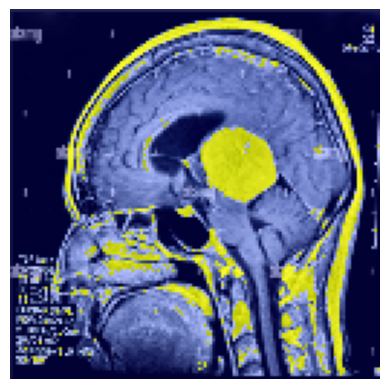

In [42]:
gradcam("/content/dataset/yes/img1.png")

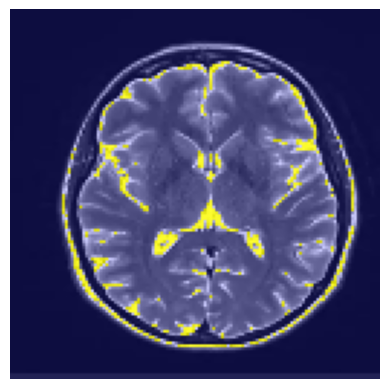

In [44]:
gradcam("/content/dataset/no/img3.png")